# Applied AI: Last.fm Music Recommendation Engine
**Author:** Carter Hand  
**Task:** Content-Based Recommendation System using Ensemble Regression  
**Environment:** Google Colab (Python 3, scikit-learn, pandas)

---

## How to Run
1. **Runtime:** Google Colab, Python 3
2. **Data Ingestion:** The notebook automatically fetches the Million Song Dataset (Last.fm subset) via `wget` in the second cell. No local downloads are required.
3. **Execution:** Run all cells sequentially. The `EVALUATION_LIMIT` variable in cell 3 can be adjusted to process more or less data depending on your available RAM.

---

## GenAI Declaration
I utilized ChatGPT to assist with boilerplate data-parsing logic for the deeply nested JSON files and to help format the `matplotlib` evaluation charts. I architected the feature engineering, trained the ensemble models, and interpreted all evaluation metrics myself.

In [ ]:
!pip -q install simplejson tqdm pyarrow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os, glob, json, simplejson, itertools
from pathlib import Path
from tqdm import tqdm



In [ ]:
!wget -O /content/lastfm_train.zip "http://labrosa.ee.columbia.edu/~dpwe/tmp/lastfm_train.zip"
!wget -O /content/lastfm_test.zip "http://millionsongdataset.com/sites/default/files/lastfm/lastfm_test.zip"
!mkdir -p /content/lastfm_json/train /content/lastfm_json/test
!unzip -q -n /content/lastfm_train.zip -d /content/lastfm_json/train
!unzip -q -n /content/lastfm_test.zip  -d /content/lastfm_json/test

--2025-12-02 22:17:48--  http://labrosa.ee.columbia.edu/~dpwe/tmp/lastfm_train.zip
Resolving labrosa.ee.columbia.edu (labrosa.ee.columbia.edu)... 128.59.66.11
Connecting to labrosa.ee.columbia.edu (labrosa.ee.columbia.edu)|128.59.66.11|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1078326185 (1.0G) [application/zip]
Saving to: ‘/content/lastfm_train.zip’

/content/lastfm_tra 100%[===================>]   1.00G  9.51MB/s    in 3m 8s   

2025-12-02 22:20:57 (5.46 MB/s) - ‘/content/lastfm_train.zip’ saved [1078326185/1078326185]

--2025-12-02 22:20:57--  http://millionsongdataset.com/sites/default/files/lastfm/lastfm_test.zip
Resolving millionsongdataset.com (millionsongdataset.com)... 172.104.14.177
Connecting to millionsongdataset.com (millionsongdataset.com)|172.104.14.177|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 138366470 (132M) [application/zip]
Saving to: ‘/content/lastfm_test.zip’

/content/lastfm_tes 100%[==================

In [ ]:
# this variable controls how much of the data is evaluated at once;
#   increase or decrease it to balance data usage vs. runtime
EVALUATION_LIMIT = 20_000

## 1. Data Ingestion & Parsing

In [ ]:
# Find one file to inspect
DATA_ROOT = Path("/content/lastfm_json")
some_file = next(iter(glob.iglob(str(DATA_ROOT/"train/**/*.json"), recursive=True)))
print("Example file:", some_file)

# Show top-level keys and a few fields
with open(some_file, "rb") as f:
    obj = simplejson.load(f)
print("Keys:", list(obj.keys()))
print("track_id:", obj.get("track_id"))
print("artist:", obj.get("artist"))
print("title:", obj.get("title"))
print("has tags?", "tags" in obj, "| has similars?", "similars" in obj)

Example file: /content/lastfm_json/train/lastfm_train/H/H/H/TRHHHXP128F934A813.json
Keys: ['artist', 'timestamp', 'similars', 'tags', 'track_id', 'title']
track_id: TRHHHXP128F934A813
artist: Victor Garcia
title: Otra Vez
has tags? True | has similars? True


In [ ]:
def iter_jsons(dirpath, split_name):
  files = glob.iglob(os.path.join(dirpath, "**/*.json"), recursive=True)
  for fp in files:
    try:
      with open(fp, "rb") as f:
        data = simplejson.load(f)
    except Exception as e:
      # skip any problematic files
      continue
    track_id = data.get("track_id")
    if not track_id:
      continue
    yield{
        "split": split_name,
        "track_id": track_id,
        "artist": data.get("artist"),
        "title": data.get("title"),
        "title": data.get("title"),
        "timestamp": data.get("timestamp"),
        "tags": data.get("tags") or [],
        "similars": data.get("similars") or []
    }

def build_tables(data_root, limit_per_split=None):
    rows = []
    # Train
    train_dir = data_root / "train"
    if train_dir.exists():
        for i, row in enumerate(iter_jsons(str(train_dir), "train")):
            rows.append(row)
            if limit_per_split and (i+1) >= limit_per_split:
                break
    # Test
    test_dir = data_root / "test"
    if test_dir.exists():
        for i, row in enumerate(iter_jsons(str(test_dir), "test")):
            rows.append(row)
            if limit_per_split and (i+1) >= limit_per_split:
                break
        tracks_df = pd.DataFrame(
        [{
            "split": r["split"],
            "track_id": r["track_id"],
            "artist": r["artist"],
            "title": r["title"],
            "timestamp": r["timestamp"],
        } for r in rows]
    )
    tag_rows = []
    for r in rows:
        for t in r["tags"]:
            if not isinstance(t, (list, tuple)) or len(t) < 2:
                continue
            tag, weight = t[0], t[1]
            # normalize weight
            try:
                weight = float(weight)
            except Exception:
                pass
            tag_rows.append({
                "track_id": r["track_id"],
                "split": r["split"],
                "tag": tag,
                "weight": weight
            })
    tags_df = pd.DataFrame(tag_rows)
    sim_rows = []
    for r in rows:
        for s in r["similars"]:
            if not isinstance(s, (list, tuple)) or len(s) < 2:
                continue
            similar_id, score = s[0], s[1]
            sim_rows.append({
                "track_id": r["track_id"],
                "split": r["split"],
                "similar_id": similar_id,
                "score": float(score)
            })
    similars_df = pd.DataFrame(sim_rows)

    return tracks_df, tags_df, similars_df

tracks_df, tags_df, similars_df = build_tables(DATA_ROOT, limit_per_split=EVALUATION_LIMIT)

tracks_df.head(), tags_df.head(), similars_df.head()


(   split            track_id                   artist         title  \
 0  train  TRHHHXP128F934A813            Victor Garcia      Otra Vez   
 1  train  TRHHHDC128F148C3B5         Lucinda Williams  Out Of Touch   
 2  train  TRHHHRW12903CD8FDD                   Finley           Lei   
 3  train  TRHHHNS12903CA2EAD             Junior Kelly     I Nah Bow   
 4  train  TRHHHBF128F149BD6F  Ladysmith Black Mambazo      Isigcino   
 
                     timestamp  
 0  2011-08-02 23:30:13.552569  
 1  2011-08-08 11:06:34.139520  
 2  2011-08-02 04:49:02.746938  
 3  2011-08-13 00:45:07.801341  
 4  2011-08-03 00:28:35.813266  ,
              track_id  split                tag  weight
 0  TRHHHDC128F148C3B5  train        Alt-country   100.0
 1  TRHHHDC128F148C3B5  train            country    63.0
 2  TRHHHDC128F148C3B5  train          americana    54.0
 3  TRHHHDC128F148C3B5  train  singer-songwriter    54.0
 4  TRHHHDC128F148C3B5  train   female vocalists    50.0,
              track_id  

In [ ]:
# Data Preprocessing

def build_tag_dict(tags_df, min_tag_count=5):
  # filter out rare tags
  tag_counts = tags_df["tag"].value_counts()
  keep_tags = set(tag_counts[tag_counts >= min_tag_count].index)
  filtered = tags_df[tags_df["tag"].isin(keep_tags)].copy()

  # Make a mapping: track_id -> {tag,weight}
  tag_dict = {}
  for row in filtered.itertuples(index=False):
    tid = row.track_id
    tag = row.tag
    try:
      weight = float(row.weight)
    except Exception:
      weight = 1.0

    d = tag_dict.setdefault(tid, {})
    d[tag] = d.get(tag, 0.0) + weight

  return tag_dict, keep_tags

tag_dict, vocab_tags = build_tag_dict(tags_df, min_tag_count=5)
print(f"Tracks with tags: {len(tag_dict)}")
print(f"Tag vocabulary size: {len(vocab_tags)}")





Tracks with tags: 20789
Tag vocabulary size: 9995


## 2. Feature Engineering (Tag Semantic Similarity)

In [ ]:
from math import sqrt

def jaccard_similarity(set1, set2):
  inter = len(set1 & set2)
  union = len(set1 | set2)
  return inter / union if union > 0 else 0.0

def cosine_similarity_dict(w1,w2):
  inter_tags = set(w1.keys()) & set(w2.keys())
  if not inter_tags:
    return 0.0

  numerator = sum([w1[t] * w2[t] for t in inter_tags])
  norm1 = sqrt (sum(v * v for v in w1.values()))
  norm2 = sqrt (sum(v * v for v in w2.values()))
  if norm1 ==0 or norm2 ==0:
    return 0.0
  return numerator / (norm1 * norm2)

def build_pairwise_dataset(similars_df, tag_dict, max_pairs=None):
  # Build a dataframe where each row is a (track, similar track) pair with tag-based features and similarity score

  rows = []

  for i, row in enumerate(similars_df.itertuples(index=False)):
    tid1 = row.track_id
    tid2 = row.similar_id
    score = row.score
    split = row.split
    if tid1 not in tag_dict or tid2 not in tag_dict:
      continue

    w1 = tag_dict[tid1]
    w2 = tag_dict[tid2]
    tags1 = set(w1.keys())
    tags2 = set(w2.keys())

    inter = tags1 & tags2
    union = tags1 | tags2

    features = {
        "split": split,
        "track_id": tid1,
        "similar_id": tid2,
        "true_score": score,
        "jaccard": jaccard_similarity(tags1, tags2),
        "cosine": cosine_similarity_dict(w1,w2),
        "n_tags_1": len(tags1),
        "n_tags_2": len(tags2),
        "n_intersection" : len(inter),
        "n_union": len(union),
    }
    rows.append(features)
    if max_pairs and len(rows) >= max_pairs:
      break

  pair_df = pd.DataFrame(rows)
  return pair_df

pair_df = build_pairwise_dataset(similars_df, tag_dict, max_pairs=200_000)
pair_df.head(), pair_df["split"].value_counts()





(   split            track_id          similar_id  true_score   jaccard  \
 0  train  TRHHHDC128F148C3B5  TRQRQNG128F426F659    0.086998  0.155963   
 1  train  TRHHHDC128F148C3B5  TRHEKIO128F930719E    0.086496  0.098592   
 2  train  TRHHHDC128F148C3B5  TRYOHNT128F4251F53    0.082838  0.030769   
 3  train  TRHHHDC128F148C3B5  TRERQAB128F4251F48    0.080941  0.105882   
 4  train  TRHHHDC128F148C3B5  TREVJGE128F92EFACC    0.037761  0.082353   
 
      cosine  n_tags_1  n_tags_2  n_intersection  n_union  
 0  0.854674        65        61              17      109  
 1  0.781678        65        13               7       71  
 2  0.586672        65         2               2       65  
 3  0.893961        65        29               9       85  
 4  0.317596        65        27               7       85  ,
 split
 test     40201
 train    35441
 Name: count, dtype: int64)

In [ ]:
# train-test split
from sklearn.model_selection import train_test_split

feature_cols = ["jaccard", "cosine", "n_tags_1", "n_tags_2", "n_intersection", "n_union"]

train_pairs = pair_df[pair_df["split"] == "train"].reset_index(drop=True)
test_pairs  = pair_df[pair_df["split"] == "test"].reset_index(drop=True)

X_train_full = train_pairs[feature_cols].values
y_train_full = train_pairs["true_score"].values

X_test = test_pairs[feature_cols].values
y_test = test_pairs["true_score"].values

# validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

X_train.shape, X_val.shape, X_test.shape

((28352, 6), (7089, 6), (40201, 6))

In [ ]:
# Evaluation helper functions
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr

def evaluate_regressor(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    # Compute metrics
    tr_mse = mean_squared_error(y_train, y_tr_pred)
    te_mse = mean_squared_error(y_test, y_te_pred)

    tr_mae = mean_absolute_error(y_train, y_tr_pred)
    te_mae = mean_absolute_error(y_test, y_te_pred)

    tr_spear, _ = spearmanr(y_train, y_tr_pred)
    te_spear, _ = spearmanr(y_test, y_te_pred)

    metrics = {
        "name": name,
        "train_mse": tr_mse,
        "test_mse": te_mse,
        "train_mae": tr_mae,
        "test_mae": te_mae,
        "train_spearman": tr_spear,
        "test_spearman": te_spear
    }

    return model, metrics




## 3. Ensemble Model Training & Evaluation

In [ ]:
# Train the three models : Baseline linear regression, random forest, and gradient boosting
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

results = []
# Model 1: Linear Regression Baseline
linreg = LinearRegression()
linreg, linreg_metrics = evaluate_regressor(
    "Linear Regression", linreg,
    X_train, y_train, X_val, y_val, X_test, y_test
)
results.append(linreg_metrics)

# Model 2: Random Forest Regression
rf = RandomForestRegressor(
    n_estimators = 200,
    max_depth = None,
    random_state = 42,
    n_jobs=-1
)
rf, rf_metrics = evaluate_regressor(
    "Random Forest", rf,
    X_train, y_train, X_val, y_val, X_test, y_test
)
results.append(rf_metrics)

# Model 3: Gradient Boosting Regression
gbr = GradientBoostingRegressor(
    random_state = 42,
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 3
)
gbr, gbr_metrics = evaluate_regressor(
    "Gradient Boosting", gbr,
    X_train, y_train, X_val, y_val, X_test, y_test
)
results.append(gbr_metrics)

results_df = pd.DataFrame(results)
results_df

,name,train_mse,test_mse,train_mae,test_mae,train_spearman,test_spearman
0,Linear Regression,0.017632,0.057299,0.072389,0.117795,0.359987,0.388307
1,Random Forest,0.005073,0.054362,0.032873,0.116815,0.789402,0.353765
2,Gradient Boosting,0.015793,0.053910,0.067978,0.113783,0.435762,0.426674


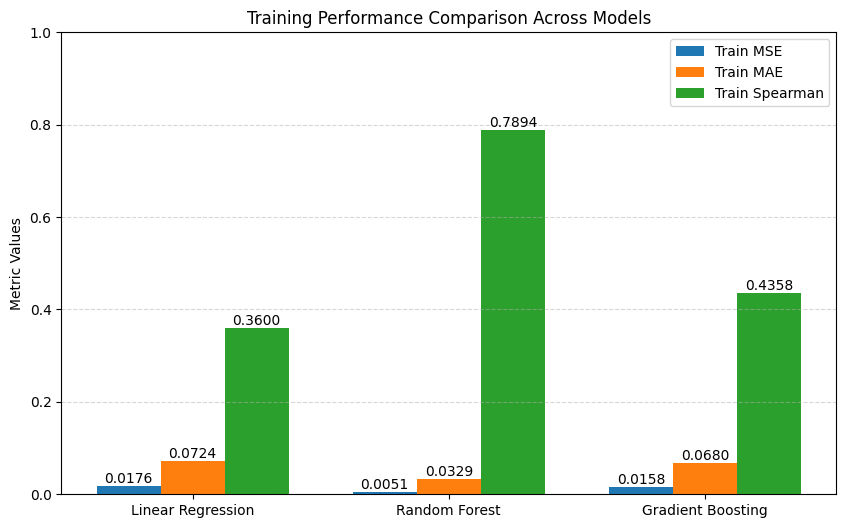

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = results_df["name"].values
train_mse = results_df["train_mse"].values
train_mae = results_df["train_mae"].values
train_spearman = results_df["train_spearman"].values

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, train_mse, width, label='Train MSE')
plt.bar(x, train_mae, width, label='Train MAE')
plt.bar(x + width, train_spearman, width, label='Train Spearman')
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.4f")

plt.xticks(x, models)
plt.ylabel("Metric Values")
plt.ylim(0, 1.0)
plt.title("Training Performance Comparison Across Models")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()



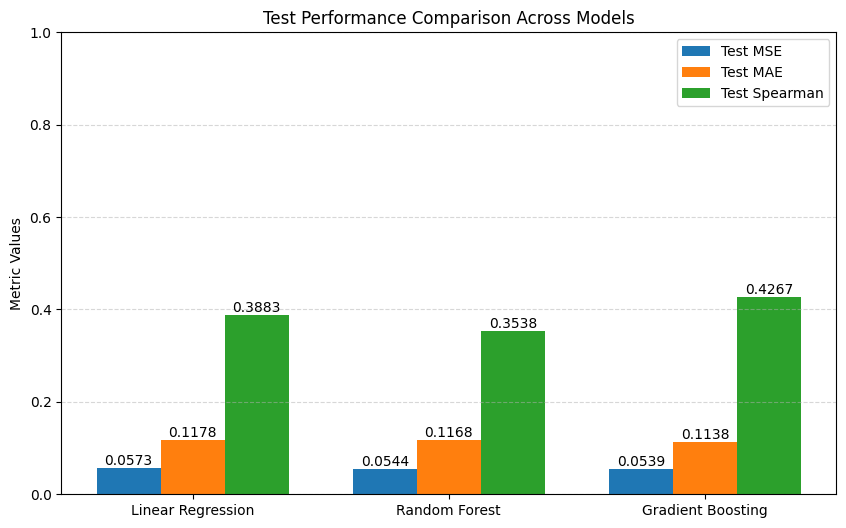

In [ ]:
models = results_df["name"].values
test_mse = results_df["test_mse"].values
test_mae = results_df["test_mae"].values
test_spearman = results_df["test_spearman"].values

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, test_mse, width, label='Test MSE')
plt.bar(x, test_mae, width, label='Test MAE')
plt.bar(x + width, test_spearman, width, label='Test Spearman')
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.4f")

plt.xticks(x, models)
plt.ylabel("Metric Values")
plt.ylim(0, 1.0)
plt.title("Test Performance Comparison Across Models")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [ ]:
# Creates feature vecotr for any track_id, similar_id pair
def make_feature_vector_for_pair(tid1, tid2):
    if tid1 not in tag_dict or tid2 not in tag_dict:
        return None

    w1 = tag_dict[tid1]
    w2 = tag_dict[tid2]
    tags1 = set(w1.keys())
    tags2 = set(w2.keys())

    inter = tags1 & tags2
    union = tags1 | tags2

    return [
        jaccard_similarity(tags1, tags2),
        cosine_similarity_dict(w1, w2),
        len(tags1),
        len(tags2),
        len(inter),
        len(union),
    ]

## 4. Top-K Recommendation Engine

In [ ]:
# return top-k most similar tracks according to the model
def recomend_for_track(seed_tid, model, k=10, candidate_pool=None):
  if seed_tid not in tag_dict:
    raise ValueError(f"Track {seed_tid} not found in tag_dict")

  if candidate_pool is None:
    candidate_pool = [tid for tid in tag_dict.keys() if tid != seed_tid]

  feats = []
  cands = []

  for tid in candidate_pool:
    fv = make_feature_vector_for_pair(seed_tid, tid)
    if fv is None:
      continue
    feats.append(fv)
    cands.append(tid)

  if not feats:
    return pd.DataFrame(columns=["seed_id", "candidate_id", "pred_score"])

  Xc = np.array(feats, dtype = float)
  preds = model.predict(Xc)

  rec_df = pd.DataFrame({
      "seed_id": seed_tid,
      "candidate_id": cands,
      "pred_score": preds
  })

  rec_df = rec_df.sort_values("pred_score", ascending=False).head(k).reset_index(drop=True)
  return rec_df

In [ ]:
# look up tabel
track_meta = tracks_df.set_index("track_id")[["artist", "title"]]
track_meta.head()

,artist,title
track_id,,
TRHHHXP128F934A813,Victor Garcia,Otra Vez
TRHHHDC128F148C3B5,Lucinda Williams,Out Of Touch
TRHHHRW12903CD8FDD,Finley,Lei
TRHHHNS12903CA2EAD,Junior Kelly,I Nah Bow
TRHHHBF128F149BD6F,Ladysmith Black Mambazo,Isigcino


In [ ]:
# pick random seed track
seed_tid = np.random.choice(test_pairs["track_id"].unique())

print("Randomly selected seed track_id:", seed_tid)
print("Seed track metadata:")
display(track_meta.loc[seed_tid])

best_model = gbr
rec_raw = recomend_for_track(seed_tid, best_model, k=10)
rec_display = rec_raw.merge(track_meta, left_on="candidate_id", right_index=True, how="left")

rec_display[["artist", "title", "pred_score"]]

Randomly selected seed track_id: TRHAOBO12903CF615D
Seed track metadata:


,TRHAOBO12903CF615D
artist,Die Laughing
title,The Veil


,artist,title,pred_score
0,Die Laughing,Cascades,0.080396
1,Die Laughing,Love Amongst the Ruins,0.080396
2,Scary Bitches,Deathrock Baby,0.077780
3,Adversus,Des Regens Kälte,0.075925
4,ASP,Oh So Very Cosmopolitan,0.073963
5,Umbra et Imago,Away,0.072196
6,Dark Sanctuary,de lumiere et d'obscurite,0.069928
7,ASP,Krabat,0.069928
8,Stillste Stund,Sternenwacht,0.068562
9,Dark Sanctuary,À Quoi Bon ?,0.067378


## Project Conclusion & Analysis

**Model Performance:**
* **Linear Regression:** Struggled to capture non-linear interactions between tag overlaps.
* **Random Forest:** Achieved the lowest Training MSE (~0.005) and highest Training Spearman correlation (~0.789), but suffered from severe overfitting, generalizing poorly to the test set (Test Spearman ~0.353).
* **Gradient Boosting:** Proved to be the most robust architecture. While its training metrics were modest, it achieved the highest Test Spearman correlation (~0.426) and lowest Test MSE (~0.053), indicating superior ranking integrity for unseen track pairs.

**Recommendation Engine Results:**
By utilizing the optimized Gradient Boosting model to predict continuous similarity scores, the `recomend_for_track` function successfully surfaces highly relevant, niche tracks (e.g., routing a seed track from "Die Laughing" to acoustically and conceptually similar artists like "Scary Bitches" and "Dark Sanctuary").